# Red FeedForward
## Integrantes:
- Martínez Marcelo Ingrid Aylen - 
- Pérez Evaristo Eris
- Ramírez Venegas Alexa Paola

Para esta práctica utilizaremos gráficas computacionales para generar una red feedforward.

1. Genera los datos de entrada por medio de la siguiente función



```
def make_classification(r0=1,r1=3,k=1000):
  """
  Creación de los datos
  """
  X1 = [np.array([r0*np.cos(t),r0*np.sin(t)]) for t in range(0,k)]
  X2 = [np.array([r1*np.cos(t),r1*np.sin(t)]) for t in range(0,k)]
  X = np.concatenate((X1,X2))
  n,d = X.shape
  Y = np.zeros(2*k)
  Y[k:] += 1
  noise = np.array([np.random.normal(0,1,2) for i in range(n)])
  X += 0.5*noise
  return X,Y
```



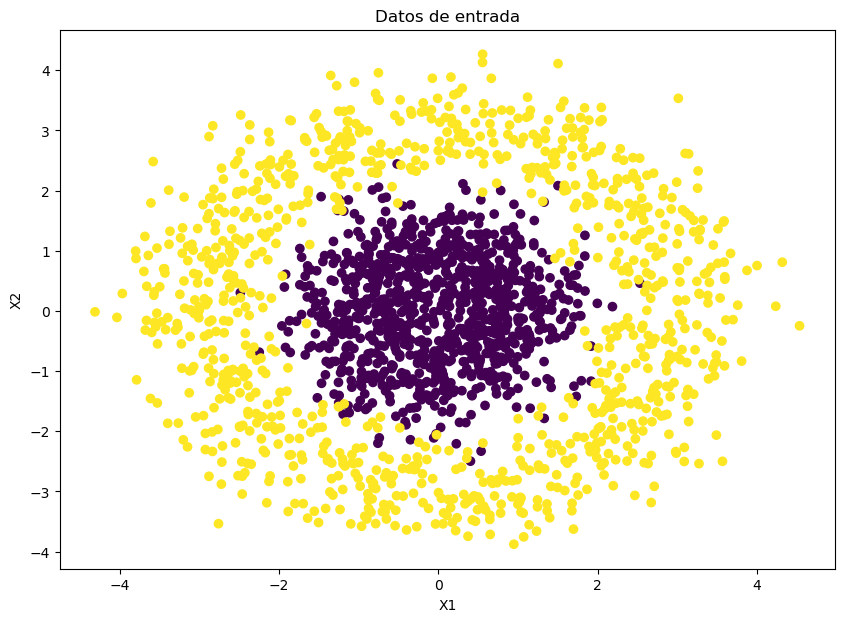

In [8]:
#Importes necesarios para la práctica como sklearn, numpy, matplotlib (Si es necesario agregar otra, agregarla aquí)

import numpy as np #numpy
from sklearn.datasets import make_classification #Clasificación
from sklearn.model_selection import train_test_split #Separación de datos
from sklearn.metrics import classification_report #Reportes
import matplotlib.pyplot as plt #Gráficas
from tqdm import tqdm #Barras de progreso

def make_classification(r0=1,r1=3,k=1000):
  """
  Creación de los datos de entrada
  """
  X1 = [np.array([r0*np.cos(t),r0*np.sin(t)]) for t in range(0,k)]
  X2 = [np.array([r1*np.cos(t),r1*np.sin(t)]) for t in range(0,k)]
  X = np.concatenate((X1,X2))
  n,d = X.shape
  Y = np.zeros(2*k)
  Y[k:] += 1
  noise = np.array([np.random.normal(0,1,2) for i in range(n)])
  X += 0.5*noise
  return X,Y

def grafica_datos():
  """
  Gráfica de los datos
  """
  X,Y = make_classification()
  plt.figure(figsize=(10,7))
  plt.scatter(X[:,0],X[:,1],c=Y)
  plt.xlabel("X1")
  plt.ylabel("X2")
  plt.title("Datos de entrada")
  plt.show()

grafica_datos()

2. Utiliza la paquetería sklearn para separar los datos en entrenamiento y evaluacion con esquema 70-30.

In [9]:
# División de dataset
# División de los datos anteriormente dados en la función make_classification donde X son las entradas y Y las etiquetas
x_train, x_eval, y_train, y_eval = train_test_split(make_classification()[0], make_classification()[1], test_size=0.3)

3. Define una clase Node que sea la superclase para los nodos de la grafica computacional, debe tener los metodos comúnes a los nodos:



```
class Node():
  """Nodo super clase con funciones generales"""
  def __init__(self, ...):
    # Agrega los par ́ametros necesarios
    
  def __call__(self, *kwargs):
    return self.forward(*kwargs)

  def __str__(self):
    return str(self.h) #Valor n ́um del nodo

  # Agrega otros métodos necesarios
```



In [10]:
class Node():
  """Nodo super clase con funciones generales"""
  def __init__(self, params = False):
    # Agrega los parámetros necesarios
    self.params = params
    self.grad = None
    
  def __call__(self, *args, **kwargs):
    return self.forward(*args, **kwargs) #Definido ya que cuando se invoque el nodo llamará en autómatico a forward

  def __str__(self):
    return str(self.h) #Valor num del nodo
  
  # Agrega otros métodos necesarios
  
  def shape(self):
    return self.h.shape
  
  def len(self):
    return len(self.h)
  
  def zero_grad(self):
    self.grad = 0

4. Debes agregar un nodo para cada una de las siguiente funciones:
- **Linear:** para las preactivaciones $wx+b$
- **ReLU:** Para la función de activación ReLU
- **Tanh:** Para la función de activación de tangente hiperbólica
- **Softmax:** Para activación softmax
- **CrossEntropy:** Para función de objetivo de entropía cruzada


In [ ]:
class Linear(Node):
    def __init__(self, input_size, output_size):
       super().__init__(params= True)
       self.w = np.random.randn(input_size, output_size) * 0.1 # Inicializamos los pesos con una distribución normal
       self.b = np.zeros((1, output_size)) # Inicializamos el bias con 0
       self.x = None
       self.act = None

    def forward(self, x): #Creo que call hace referencia al forward
      """ Función de llamado de la capa, funciona como el forward.
      Args:
        - x (array): Entrada en arreglo.
      Returns:
        - Nodo de preactivación.
      """
      self.x = x
      self.act = np.dot(x, self.w) + self.b
      return self.act
    
    def backward(self, consumer_grad, lr=0.1):
      """ Función backward de la capa
      Args:
        - consumer_grad (array): gradiente del nodo posterior.
        - lr (float): tasa de aprendizaje
      Returns:
        - Gradiente del nodo de preactivación
      """
      m = self.x.shape[0]                          # Núm de muestras
      dw = np.dot(self.x.T, consumer_grad) / m     # Gradiente respecto a W
      db = np.mean(consumer_grad, axis=0, keepdims=True)  # Gradiente respecto a b
      grad = np.dot(consumer_grad, self.w.T) # Gradiente respecto a la entrada que nos pasan

      # Actualización de parámetros
      self.w -= lr * dw
      self.b -= lr * db

      # Gradiente que se pasa hacia atrás (para capas previas a PreActivacion)
      return grad

class ReLU(Node):
    def __init__(self):
        """Inicialización del nodo ReLu"""
        super().__init__()
        self.x = None
        self.act = None

    def forward(self, x):
        """Funciona para que el nodo invocado utilice la función ReLU"""
        self.x = x
        self.act = np.maximum (0, x)
        return self.act
    
    def backward(self, consumer_grad):
        """Backard del nodo con función ReLU"""
        consumer_grad = consumer_grad * (self.x > 0).astype(float) #Derivada de la función ReLU
        return consumer_grad #Regresamos a capas donde fue mayor a 0

class Tanh(Node):
    """Nodo con función de tangente hiperbólica"""
    def __init__(self):
        """Inicialización del nodo"""
        super().__init__()
        self.act = None
        self.x = None
    
    def forward(self, x):
        """Función para que el nodo invocado utilice la tangente hiperbólica"""
        self.x = x
        self.act = np.tanh(x)
        return self.act
    
    def backward(self, consumer_grad):
        consumer_grad = consumer_grad * (1 - np.tanh(self.x) ** 2)
        return consumer_grad

class Softmax(Node):
    """Nodo con la función de salida Softmax"""
    def __init__(self):
        super().__init__()
        self.act = None 
    
    def forward(self, x, axis = 1):
        """Función para que el nodo invocado utilice la función softmax""" 
        exps = np.exp(x - np.max(x, axis=axis, keepdims = True))
        self.act = exps / np.sum(exps, axis=axis, keepdims = True)
        return self.act
    def backward(self, consumer_grad):
        consumer_grad = consumer_grad * (self.act * (1 - self.act))
        return consumer_grad

class CrossEntropy(Node):
  """ Clase del nodo Entropía Cruzada para regresión logística
  Author:
    Martínez Marcelo Ingrid Aylen
    Pérez Evaristo Eris
    Ramírez Venegas Alexa Paola
  """
  def forward(self, x, y):
    """ Función call sobreescrita para ser llamada al usar el nodo para la función de pérdida con los parámetros de la etiqueta real y la predicción
    Args:
      - x (array): predicción
      - y (array): etiqueta real
    Returns:
      - Nodo de entropía cruzada
    """
    self.x = x
    self.y = y
    eps = 1e-9 # Para evitar log(0)
    perdida = -np.mean(np.sum(y * np.log(x + eps), axis=1))
    return perdida

  def backward(self):
    """ Función backward del nodo de entrpía cruzada
    Returns:
      - Gradiente del nodo de entropía cruzada
    """
    m = self.y.shape[0]
    grad = (self.x - self.y) / m
    return grad

class Sequential(Node):
  """Clase para secuencializar capas"""
  def __init__(self, *kwargs):
    self.layers = kwargs
    self.params = []
    for layer in self.layers:
      if layer.params:
        self.params.append(layer)

  def forward(self, x):
    actual_val = x
    for layer in self.layers:
        actual_val = layer(actual_val)
    return actual_val

  def __getitem__(self, i):
    return self.layers[i]

5. La red debe tener dos neuronas de salida (una por clase) con activación Sotfmax, y dos capas ocultas, la primera con tangente hiperbólica y la segunda con ReLU. Determina el numero de unidades necesarias por cada capa.

6. Para el entrenamiento de la red sigue las siguientes pautas:
- Utiliza entre 100 y 300 épocas
- Utiliza Mini-lotes de tamaño 10
- Actualiza el optimizador de Adagrad con $\epsilon = 1e^{-8}$ y taza de aprendizaje de 0.1

7. Finalmente, evalua la clasificación obtenida. Puedes utilizar *classification_report* de la biblioteca *sklearn*.

Los puntos que se evaluaran son los siguientes:
- Implementación con la estructura de gráfica computacional, otro tipo de implementación se penalizará con 1 punto.


- Utilizar Adagrad u optimizadores más complejos (Adam). Si se utiliza descenso gradiente se penalizará con 0.5 puntos.


- Realización de la evaluación, si se carece de evaluación o de la separación de datos de evaluación se penalizará con 1 punto.


- **!!No se permite utilizar bibliotecas especializadas como Pytorch o Tensorflow,
su uso se penalizará con 3 puntos.**

# Funciones Auxiliares

Las funciones que aquí se muestran pueden apoyar a la implementación, no son necesarias utilizarlas. También, se pueden adaptar a la implementación.



* a) Función para plotear regiones de separación (requiere que el nodo de la red $f$ tenga metodo argmax, el cual regresa la clase con mayor probabilidad):



```
def draw_regions(f, x, y='black', axis=1):
  figure = plt.figure()
  min1, max1 = x[:, 0].min()-1, x[:, 0].max()+1
  min2, max2 = x[:, 1].min()-1, x[:, 1].max()+1
  x1grid = np.arange(min1, max1, 0.1)
  x2grid = np.arange(min2, max2, 0.1)
  xx, yy = np.meshgrid(x1grid, x2grid)
  r1, r2 = xx.flatten(), yy.flatten()
  r1, r2 = r1.reshape((len(r1), 1)), r2.reshape((len(r2), 1))
  grid = np.hstack((r1,r2))
  yhat = f(grid).argmax(axis)
  zz = yhat.reshape(xx.shape)
  plt.contourf(xx, yy, zz, alpha=0.6)

  plt.scatter(x[:,0], x[:,1],c=y,s=2)

  return figure
```

* b) Clase para secuencializar los nodos (requiere que los nodos tengan un parámetro de atributo que es _True_ si el nodo tiene pesos a actualizar y _False_ si no)



```
class Sequential(Node):
  """Clase para secuencializar capas"""
  def __init__(self, *kwargs):
    self.layers = kwargs
    self.params = []
    for layer in self.layers:
      if layer.params:
        self.params.append(layer)

  def forward(self, x):
    actual_val = x
      for layer in self.layers:
        actual_val = layer(actual_val)
      return actual_val

  def __getitem__(self, i):
    return self.layers[i]
```
